# scTRAM Benchmarking for HDCA (Human Developmental Cell Atlas)

In [1]:
0

0

In [2]:
import sys

working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)

import gc
import itertools
import logging
import os
import pickle
import subprocess
import sqlite3
import time
import h5py

from pandas.api.types import is_object_dtype
import anndata as ad
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import tqdm

sc.settings.verbose = 3

In [3]:
from helper.get_hdca_trainings_with_paths import get_hdca_trainings_with_paths
from helper.pickle_operations import save_pickle_bundle, load_pickle_bundle
from helper.csv_operations import (
    harmonize_union_with_report,
    analyze_column_consistency,
    combine_dataframes_on_columns
)

from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.generate.real import sc_suo_developmental_complete
from sctram.input import InputTrajectories

2025-05-07 10:08:58.697 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-05-07 10:08:58.698 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [4]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

import colorcet as cc
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from matplotlib import gridspec
from networkx.drawing.nx_agraph import graphviz_layout

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [5]:
def is_job_running(job_name):
    result = subprocess.run(
        ["squeue", "-o", "%.28i %.28j %.28u %R", "-u", "kemal.inecik"], capture_output=True, text=True
    )
    jobs = [[j.strip() for j in i.split()] for i in result.stdout.strip().split("\n")]
    for jobid, jobname, jobuser, jobnode in jobs:
        if job_name == jobname:
            return True
    return False

In [6]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

Slurm Settings for reference:

- gpu:
  
    ```
    #SBATCH -J {job_name}
    #SBATCH -p gpu_p
    #SBATCH --qos=gpu_normal
    #SBATCH --gres=gpu:1
    #SBATCH -c 6
    #SBATCH --mem=159G
    #SBATCH --nice=0
    #SBATCH -t 23:50:00
    #SBATCH -o {:log_file}
    #SBATCH -e {log_file}
    ```

- cpu:
  
    ```
    #SBATCH -J {job_name}
    #SBATCH -p cpu_p
    #SBATCH --qos cpu_normal
    #SBATCH -c 32
    #SBATCH --mem=159G
    #SBATCH --nice=0
    #SBATCH -t 1-23:50:00
    #SBATCH -o {log_file}
    #SBATCH -e {log_file}
    ```

## Datasets to Benchmark

In [46]:
df_hdca, df_hdca_lvl2, df_hdca_lvl3 = get_hdca_trainings_with_paths()
df_hdca_lvl3_adata_paths = df_hdca_lvl3.drop_duplicates(subset=["model"], keep='first')[["model", "experiment_id", "dataset"]].copy()
df_hdca_lvl3_adata_paths = {i: {"latent": j, "dataset": k} for i, j, k in list(df_hdca_lvl3_adata_paths.values)}
df_hdca_lvl3_adata_paths

{'scvi': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/20240613_152640100145_gpusrv44.scidom.de_2367215.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'scpoli': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/20240614_182544898191_gpusrv74.scidom.de_567700.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'harmony': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/harmony_concatenate_unification_union_20240330_hvg-intersection_integration.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'pca': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/pca_unification_union_20240330_hvg_integrat

In [47]:
trajectory_annotation_csv_path = dict(
    germline = '/lustre/groups/ml01/workspace/kemal.inecik/hdca/data/metadata/partial_annotation_for_trajectory/Germline_harm_20250407.csv',
    haem = '/lustre/groups/ml01/workspace/kemal.inecik/hdca/data/metadata/partial_annotation_for_trajectory/Haem_harm_20250407.csv',
    pns_neuro_glia = '/lustre/groups/ml01/workspace/kemal.inecik/hdca/data/metadata/partial_annotation_for_trajectory/PNS_neuro_glia_harm_20250407.csv',
)

trajectory_annotation_csv = dict()
for i, j in trajectory_annotation_csv_path.items():
    k = pd.read_csv(j)
    k.set_index("Unnamed: 0", drop=True, inplace=True, verify_integrity=True)
    k.index.name = None
    trajectory_annotation_csv[i] = k

/tmp/ipykernel_4046737/2394884048.py:9: DtypeWarning: Columns (17,20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  k = pd.read_csv(j)
/tmp/ipykernel_4046737/2394884048.py:9: DtypeWarning: Columns (8,22,41) have mixed types. Specify dtype option on import or set low_memory=False.
  k = pd.read_csv(j)


In [48]:
intersecting_columns_csv, differing_columns_csv = analyze_column_consistency(trajectory_annotation_csv)
trajectory_annotation_csv_combined = combine_dataframes_on_columns(trajectory_annotation_csv, sorted(intersecting_columns_csv))

In [49]:
with h5py.File(df_hdca_lvl3_adata_paths["scpoli"]["latent"]) as f:
    adata_scvi_latent_obs = ad.io.read_elem(f["obs"])

In [50]:
out_df, mismatch_df, missing_df = harmonize_union_with_report(trajectory_annotation_csv_combined, adata_scvi_latent_obs)

In [51]:
display(adata_scvi_latent_obs.columns)
display(trajectory_annotation_csv_combined.columns)

Index(['handle_anndata', 'study', 'sample_ID', 'organ', 'age', 'cell_type',
       'integration_donor', 'integration_biological_unit',
       'integration_sample_status', 'integration_library_platform_coarse',
       'concatenated_integration_covariates', 'LVL3', 'LVL2', 'LVL1', 'LVL0',
       '_scvi_batch', '_scvi_labels'],
      dtype='object')

Index(['LVL0', 'LVL1', 'LVL2', 'LVL3', 'age', 'anatomical_region',
       'anatomical_region_level_2', 'author_batch', 'biological_unit',
       'broad_anno', 'cell_enrichment', 'cell_type',
       'concatenated_integration_covariates', 'doi', 'handle_anndata',
       'institute', 'integration_biological_unit', 'integration_donor',
       'integration_library_platform_coarse', 'integration_sample_status',
       'lane_ID', 'leiden', 'library_platform', 'organ',
       'original_author_annotation', 'protocol_tissue_dissociation',
       'reads_processing', 'ref_anno1', 'ref_anno2', 'reference_genome',
       'reference_genome_ensembl_release', 'sample_ID', 'sample_cultured',
       'sample_status', 'sequencing_platform', 'sex', 'sex_inferred',
       'strand_sequence', 'study', 'study_PI', 'subject_type', 'csv_key'],
      dtype='object')

In [52]:
mismatch_df

,LVL0_new,LVL0_big,LVL1_new,LVL1_big
Colin_TTCAATCAGCGAACTG_1-PCW12,Endothelial,Neuronal_and_Glial,Endothelial,Neuronal
Colin_GTTAGACTCTCGCAGG_1-PCW16,Endothelial,Neuronal_and_Glial,Endothelial,Neuronal
Colin_TCCTTTCTCCACATAG_3-PCW20,Endothelial,Neuronal_and_Glial,Endothelial,Neuronal
Colin_TTAGGCACATGAGGGT_3-PCW20,Endothelial,Neuronal_and_Glial,Endothelial,Neuronal
Colin_TACCTTATCATCTGCC_1-PCW20,Endothelial,Neuronal_and_Glial,Endothelial,Neuronal
...,...,...,...,...
Colin_TTGACCCGTGGAACCA_3-PCW20,Endothelial,Neuronal_and_Glial,Endothelial,Neuronal
Colin_TTGGATGGTGGACTAG_3-PCW20,Endothelial,Neuronal_and_Glial,Endothelial,Neuronal
Colin_TTGTTTGCACTCAAGT_3-PCW20,Endothelial,Neuronal_and_Glial,Endothelial,Neuronal
Colin_TTTCACAAGTTTCTTC_3-PCW20,Endothelial,Neuronal_and_Glial,Endothelial,Neuronal


In [56]:
missing_df.value_counts(['handle_anndata', "LVL3", "ref_anno2"])

handle_anndata  LVL3                     ref_anno2                      
Suo             GLIAL                    Non_myelinating_schwann_cell_2     3027
                                         Enteric_glia                       1660
                                         SCP                                1076
                                         Schwann_cell_1                     1065
                                         Autonomic_glial_progenitor          696
                                         SCP_4                               308
Braun           Brain erythrocytes       Erythroid_6                         163
Suo             VSMC_PERICYTE_III        Erythroid_2_route_2                  30
                GLIAL                    Non_myelinating_schwann_cell_1       24
He              Definitive erythrocytes  Erythroid_5                          24
Suo             GLIAL                    Enteric_neuron                       15
                                    

### Training the Atlas Components

In [13]:
job_count = 0
overwrite = False

cpu_gpu = "gpu"
df_hdca_component_adata_paths = dict()

with h5py.File(df_hdca_lvl3_adata_paths["scvi"]["dataset"]) as f:
    unique_handle_anndata = ad.io.read_elem(f["obs/handle_anndata"]).unique()

for handle_anndata in unique_handle_anndata:
    
    for model_str in ["scvi"]:
        
        adata_file_path = "/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad"
        trained_model_path = f"/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unification_union_20240330_hvg-intersection_integration_{handle_anndata}_scvi"
        trained_latent_path = f"/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unification_union_20240330_hvg-intersection_integration_{handle_anndata}_scvi.h5ad"

        log_file = os.path.join(logs_directory, f"scvi_component_{cpu_gpu}_{model_str}_{handle_anndata}.log")
        job_name = f"prep_{model_str}_{handle_anndata}"
        python_name = f"scvi_individual.py"

        if is_job_running(job_name):
            print(f"Training {job_name!r} on {cpu_gpu!r} keeps going.")
        elif overwrite or not os.path.exists(trained_latent_path) or not os.path.isfile(trained_latent_path):
            try:
                slurm_script = f"""#!/bin/bash
#SBATCH -J {job_name}
#SBATCH -p gpu_p
#SBATCH --qos=gpu_normal
#SBATCH --gres=gpu:1
#SBATCH -c 18
#SBATCH --mem=481G
#SBATCH --nice=0
#SBATCH -t 23:50:00
#SBATCH -o {log_file}
#SBATCH -e {log_file}

source activate hdca_integration_env
python -u {os.path.join(helpers_directory, python_name)} --adata_file_path "{adata_file_path}" --trained_model_path "{trained_model_path}" --trained_latent_path "{trained_latent_path}" --handle_anndata "{handle_anndata}"
    """
                script_name = os.path.join(logs_directory, f"slurm_job_scvi_component_{cpu_gpu}_{model_str}_{handle_anndata}.sh")
                with open(script_name, "w") as f:
                    f.write(slurm_script)

                print(f"Submitted job {job_count+1}: {job_name!r}")
                subprocess.run(["sbatch", script_name])
                job_count += 1
            finally:
                # time.sleep(0.05)
                os.remove(script_name)

            assert is_job_running(job_name), f"Training {job_name!r} on {cpu_gpu!r} error."
        else:
            print(f"Model exists for {model_str!r} of {handle_anndata!r}")

        df_hdca_component_adata_paths[handle_anndata] = {"latent": trained_latent_path, "dataset": adata_file_path}
    # if job_count > 32:
    #     break

print(f" - Number of jobs submitted: {job_count}")

Model exists for 'scvi' of 'Braun'
Model exists for 'scvi' of 'Calvanese'
Model exists for 'scvi' of 'Colin'
Model exists for 'scvi' of 'Dong'
Model exists for 'scvi' of 'Garcia'
Model exists for 'scvi' of 'He'
Model exists for 'scvi' of 'Kanemaru'
Model exists for 'scvi' of 'Lawrence'
Model exists for 'scvi' of 'Miller'
Model exists for 'scvi' of 'Sridhar'
Model exists for 'scvi' of 'Suo'
Model exists for 'scvi' of 'To'
Model exists for 'scvi' of 'Yu'
Model exists for 'scvi' of 'Zhang'
 - Number of jobs submitted: 0


In [14]:
df_hdca_component_adata_paths

{'Braun': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unification_union_20240330_hvg-intersection_integration_Braun_scvi.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'Calvanese': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unification_union_20240330_hvg-intersection_integration_Calvanese_scvi.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'Colin': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unification_union_20240330_hvg-intersection_integration_Colin_scvi.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'Dong': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unificat

##  Trajectories to Benchmark

In [15]:
ground_truth_trajectories = dict()

In [16]:
trajectory_annotation_csv["germline"]["ref_anno2"].unique()

array(['oogonia_meiotic_spin_off', 'oogonia_meiotic_2', 'PGC',
       'pre_spermatogonia', 'pre_oocyte', 'GC', 'oogonia', 'oocyte',
       'oogonia_meiotic_1'], dtype=object)

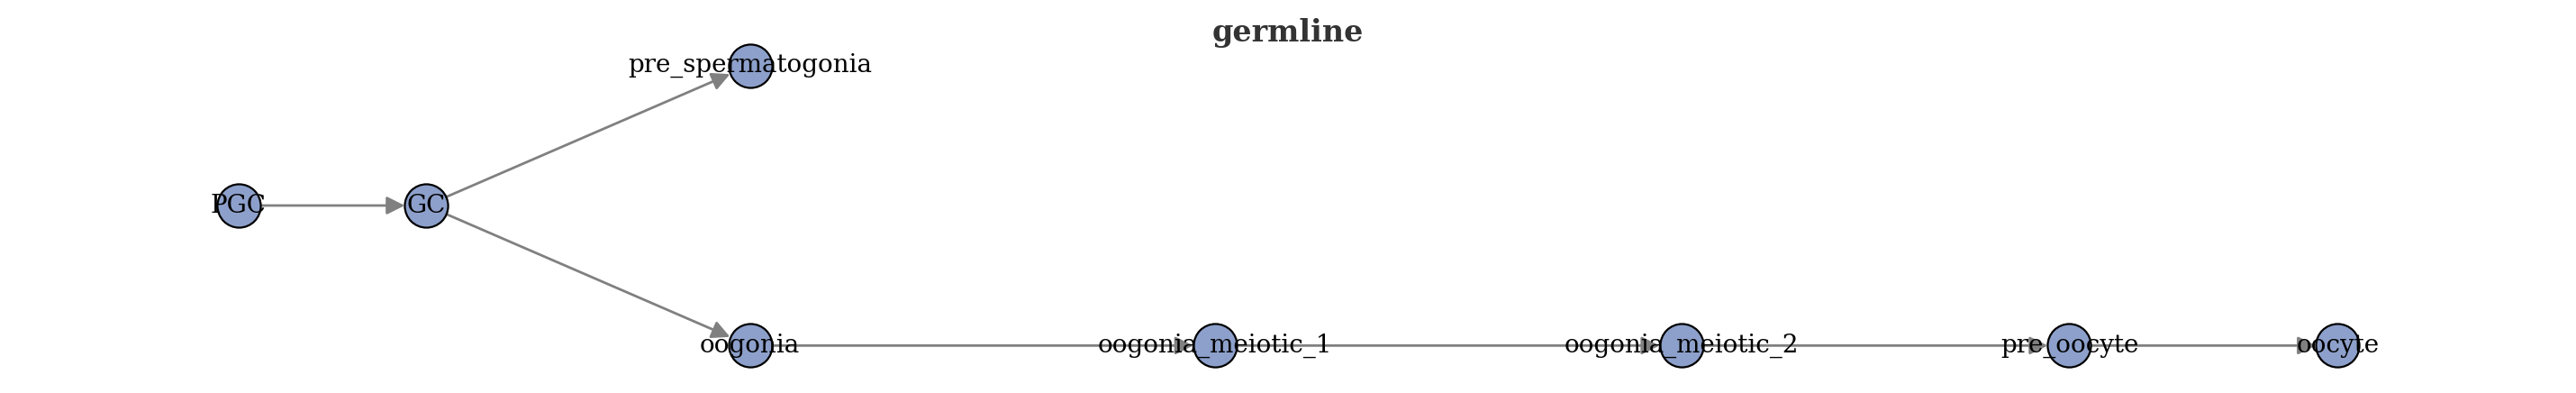

In [17]:
trajectory = "germline"
ground_truth_trajectories[trajectory] = [
    ('PGC', 'GC'),
    ('GC', 'pre_spermatogonia'),
    ('GC', 'oogonia'),
    ('oogonia', 'oogonia_meiotic_1'),
    ('oogonia_meiotic_1', 'oogonia_meiotic_2'),
    ('oogonia_meiotic_2', 'pre_oocyte'),
    ('pre_oocyte', 'oocyte')
    
]
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=False)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 2), 
    label_offset=0,
)

In [18]:
trajectory_annotation_csv["pns_neuro_glia"]["ref_anno2"].unique()

array(['SCP', 'Non_myelinating_schwann_cell_2', 'Enteric_neuron',
       'Autonomic_glial_progenitor', 'Sympathetic_neuronal_progenitor',
       'Parasympathetic_neuron_1', 'Sympathetic_neuron', 'Schwann_cell_1',
       'Parasympathetic_neuron_progenitor', 'hub_state',
       'Sensory_neuron_DRG', 'Enteric_glia', 'Chromaffin_cell',
       'Autonomic_neuronal_progenitor', 'Satellite_glia',
       'Non_myelinating_schwann_cell_1', 'Parasympathetic_neuron_2',
       'Promyelinating_schwann_cell', 'Myelinating_schwann_cell', 'SCP_3',
       'Parasympathetic_neuron', 'Sympathetic_neuron_transitioning',
       'SCP_4', 'Sensory_neuron_skin', 'Sensory_neuron_skull',
       'Sensory_neuron_nociceptive_DRG', 'SCP_5', 'SCP_2',
       'satellite_glia_progenitor'], dtype=object)

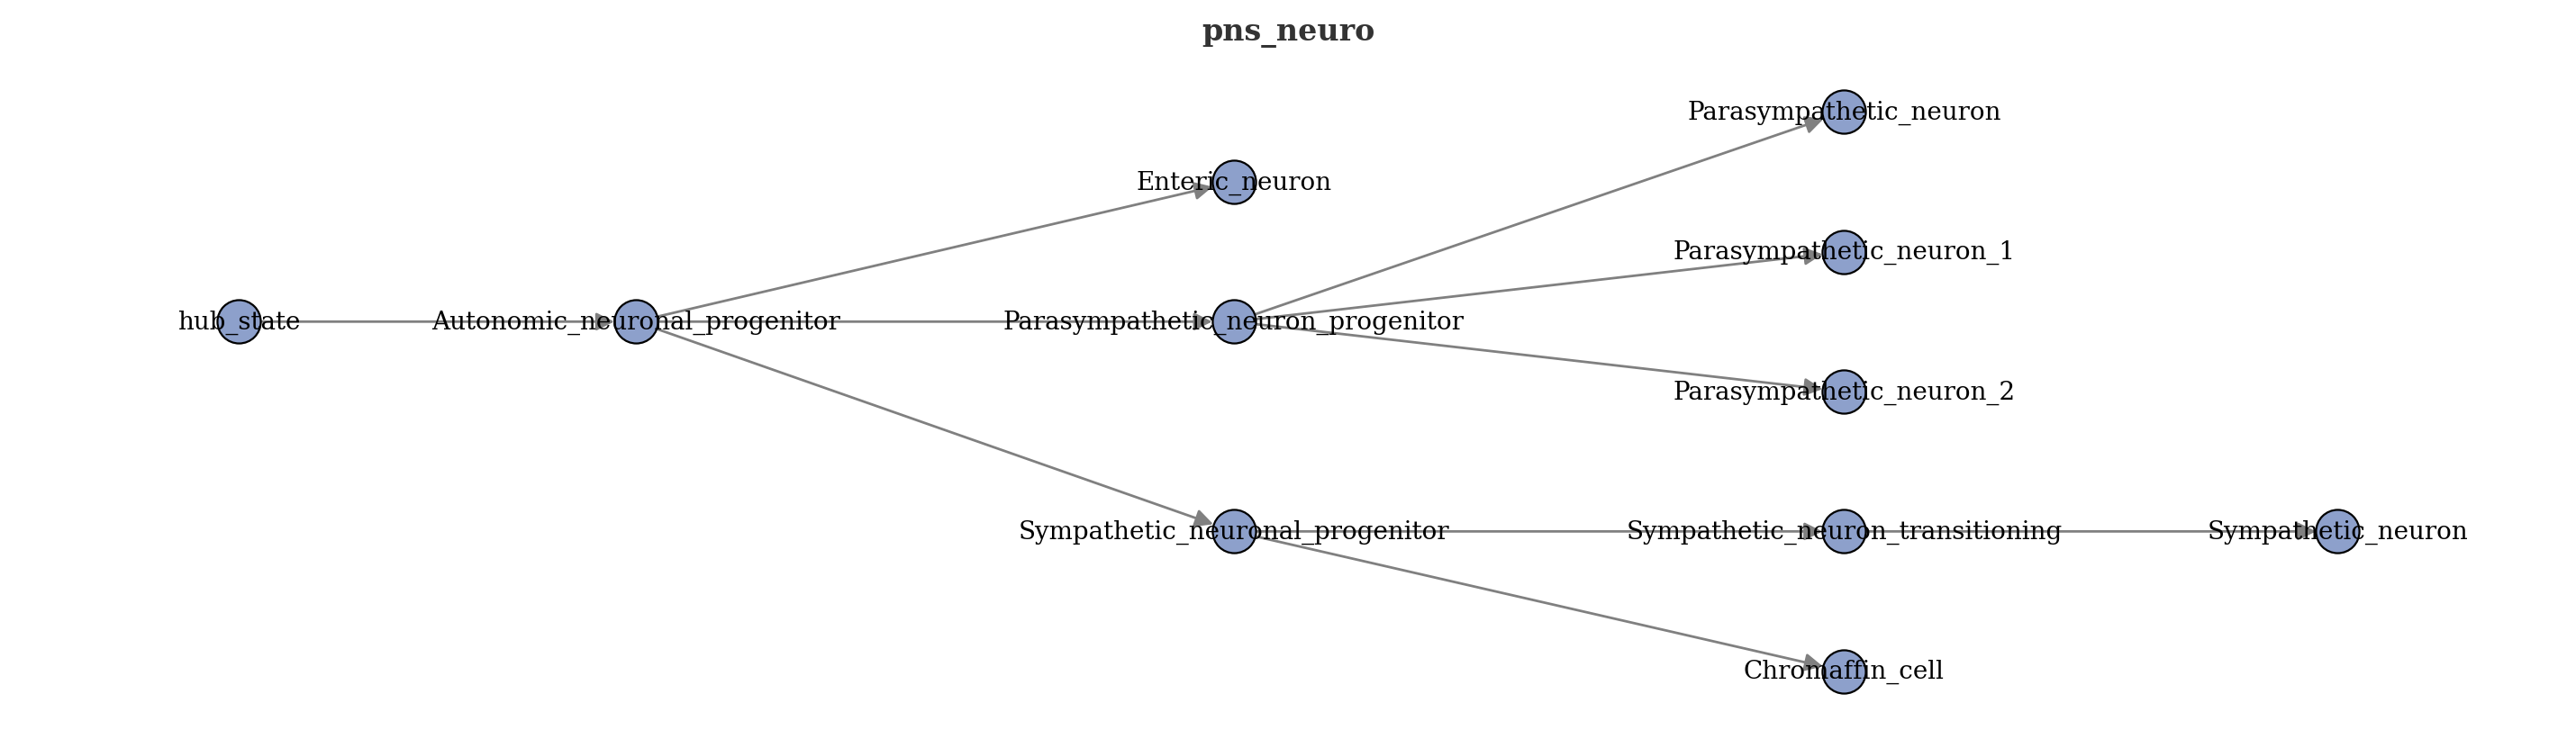

In [19]:
trajectory = "pns_neuro"
ground_truth_trajectories[trajectory] = [
    ('hub_state', 'Autonomic_neuronal_progenitor'),
    ('Autonomic_neuronal_progenitor', 'Enteric_neuron'),
    ('Autonomic_neuronal_progenitor', 'Parasympathetic_neuron_progenitor'),
    ('Autonomic_neuronal_progenitor', 'Sympathetic_neuronal_progenitor'),
    ('Parasympathetic_neuron_progenitor', 'Parasympathetic_neuron'),
    ('Parasympathetic_neuron_progenitor', 'Parasympathetic_neuron_1'),
    ('Parasympathetic_neuron_progenitor', 'Parasympathetic_neuron_2'),
    ('Sympathetic_neuronal_progenitor', 'Sympathetic_neuron_transitioning'),
    ('Sympathetic_neuron_transitioning', 'Sympathetic_neuron'),
    ('Sympathetic_neuronal_progenitor', 'Chromaffin_cell'),
]
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=False)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 4),
    label_offset=0,
)

In [20]:
# trajectory = "pns_neuro_v2"
# combine para neuron 0, 1, 2
# combine sym transitioning and sympathetic neuron

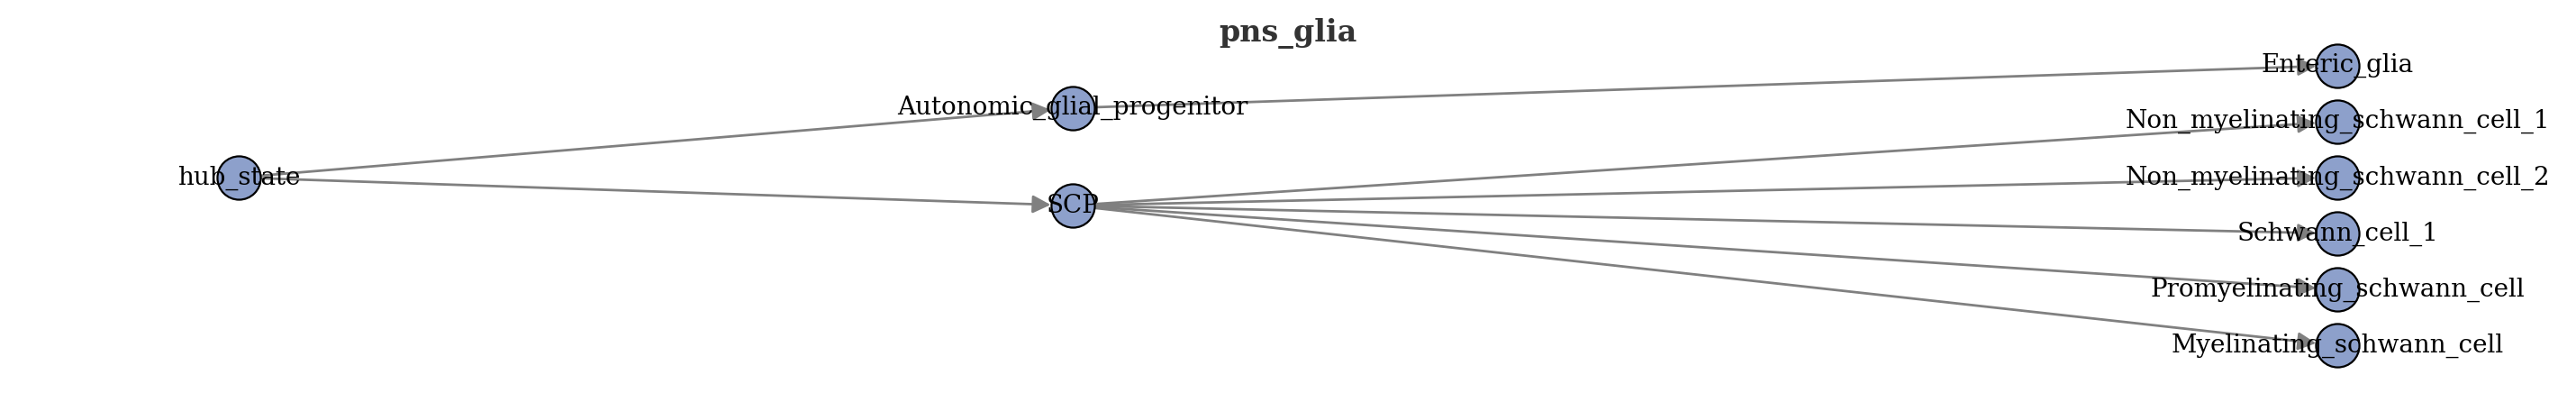

In [21]:
trajectory = "pns_glia"
ground_truth_trajectories[trajectory] = [
    ('hub_state', 'Autonomic_glial_progenitor'),
    ('Autonomic_glial_progenitor', 'Enteric_glia'),
    ('hub_state', 'SCP'),
    ('SCP', 'Non_myelinating_schwann_cell_1'),
    ('SCP', 'Non_myelinating_schwann_cell_2'),
    ('SCP', 'Schwann_cell_1'),
    ('SCP', 'Promyelinating_schwann_cell'),
    ('SCP', 'Myelinating_schwann_cell'),
]
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=False)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 2), 
    label_offset=0,
)

In [22]:
np.sort(trajectory_annotation_csv["haem"]["ref_anno2"].unique())

array(['ABT(ENTRY)', 'B1', 'CD4_T', 'CD4_T_2', 'CD8AA', 'CD8_T', 'CMP',
       'CYCLING_B', 'CYCLING_NK', 'CYCLING_T', 'DC', 'DC1',
       'DC_FCAImmP7292035_unique', 'DN(P)_T', 'DN(P)_T_2', 'DN(P)_T_3',
       'DN(Q)_T', 'DN(early)_T', 'DP(P)_T', 'DP(P)_T_2', 'DP(Q)_T',
       'EOSINOPHIL_BASOPHIL', 'Early_MK', 'Endothelial_cell',
       'Erythroid_1', 'Erythroid_2_route_1', 'Erythroid_2_route_2',
       'Erythroid_3_route_1', 'Erythroid_3_route_1_offshoot',
       'Erythroid_3_route_2', 'Erythroid_4', 'Erythroid_4_route_1',
       'Erythroid_4_route_2', 'Erythroid_5', 'Erythroid_6', 'Erythroid_7',
       'Erythroid_8', 'Erythroid_9', 'HSC_MPP_1', 'HSC_MPP_2',
       'HSC_MPP_endothelial_like', 'ILC2', 'ILC3', 'Immature_B',
       'LMPP_MLP', 'LMPP_MLP_2', 'Langerhan_cells', 'Large_pre_B',
       'Large_pre_B_FCAImmP7292035_unique', 'Late_MK', 'Late_Pro_B',
       'MAST_CELL', 'MEMP_MEP', 'MEM_like', 'MK_non_classical',
       'MOP_PROMONOCYTE', 'Macrophage_FOLR2_SPP1',
       'Macrop

In [23]:
ground_truth_trajectories.keys()

dict_keys(['germline', 'pns_neuro', 'pns_glia'])

## Running the scTRAM

In [24]:
# Saving the objects to be used in the scripts
pickle_bundle_path = os.path.join(dataset_dir, "_experiment_development_atlas_helper_pickle_bundle.pkl")
pickle_bundle = (
    df_hdca_component_adata_paths,
    df_hdca_lvl3_adata_paths,
    out_df,
    ground_truth_trajectories
)
save_pickle_bundle(pickle_bundle_path, pickle_bundle)

# (
#     df_hdca_component_adata_paths,
#     df_hdca_lvl3_adata_paths,
#     out_df,
#     ground_truth_trajectories,
# ) = load_pickle_bundle(pickle_bundle_path)

In [25]:
_input_trajectory = InputTrajectories(ground_truth_trajectories)

In [26]:
# scvi vs scpoli etc

In [27]:
set(_input_trajectory.get_trajectory("germline", include_additional_nodes=False).nodes())

{'GC',
 'PGC',
 'oocyte',
 'oogonia',
 'oogonia_meiotic_1',
 'oogonia_meiotic_2',
 'pre_oocyte',
 'pre_spermatogonia'}

In [ ]:
adata_main[adata_main.obs.index.isin(trajectory_annotation_csv["germline"]["Unnamed: 0"])]

In [ ]:
trajectory_annotation_csv["germline"]["ref_anno2"].unique()

In [ ]:
# combine antony's annotations with the data above

In [ ]:
# set up slurm for-loop-command
# set up associated python script

In [ ]:
# run